In [8]:
import math
import matplotlib.pyplot as plt
import numpy as np
import random
%matplotlib inline

In [18]:
class Value:
    def __init__(self, data, _children = (), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self.back = lambda: None
        self._op = _op
        self.label = label
    def __add__(self, n):
        n = n if isinstance(n, Value) else Value(n)
        o = Value(self.data + n.data, (self, n), "+")
        def backward():
            self.grad += o.grad * 1.0
            n.grad += o.grad * 1.0
        o.back = backward
        return o
    def __mul__(self, n):
        n = n if isinstance(n, Value) else Value(n)
        o = Value(self.data * n.data, (self, n), "*")
        def backward():
            self.grad += o.grad * n.data
            n.grad += o.grad * self.data
        o.back = backward
        return o
    def __pow__(self, n):
        o = Value(self.data ** n, (self, ), "pow")
        def backward():
            self.grad += n*(self.data**(n-1))*o.grad
        o.back = backward
        return o
    def tanh(self):
        o = Value(math.tanh(self.data), (self, ), "tanh")
        def backward():
            self.grad += o.grad * (1 / math.cosh(self.data)**2)
        o.back = backward
        return o
    def __rmul__(self, n):
        return self * n
    def __truediv__(self, n):
        return self * n**-1
    def __neg__(self):
        return self * -1;
    def __sub__(self, n):
        return self + -n
    def backward(self):
        visited = set()
        topo = []
        self.grad = 1.0
        def build_topo(a):
            if(a not in visited):
                visited.add(a)
                for child in a._prev:
                    build_topo(child)
                topo.append(a)
        build_topo(self)
        for item in reversed(topo):
            item.back()
        
        

In [19]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # for any Value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{data = %.4f | var = %s | grad = %.4f}" % (n.data, n.label, n.grad) ,
            shape='record'
        )
        if n._op:
            # if this Value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)

            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

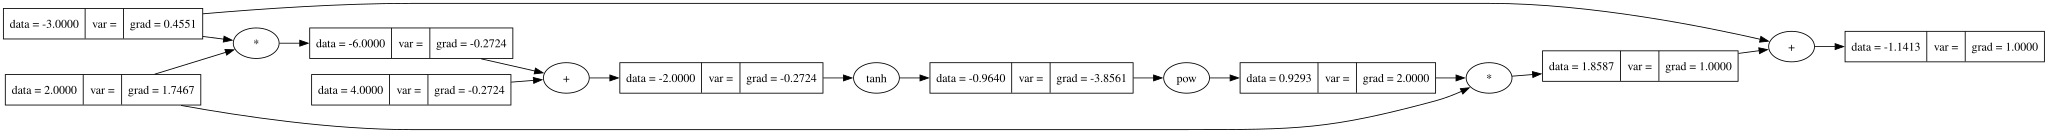

In [20]:
a = Value(2.0)
b = Value(-3.0)
c = Value(4.0)

d = a * b
e = d + c
f = e.tanh()
g = f ** 2
h = g * a
out = h + b

out.backward()

draw_dot(out)

In [76]:
def forward_pass(a, b, c, d):
    x1 = a * b
    x2 = c * d
    
    x3 = x1 + x2
    x4 = x3 * a
    
    x5 = x4 + b
    x6 = x5.tanh()
    
    x7 = x6 ** 2
    x8 = x7 * c
    
    x9 = x8 + x2
    x10 = x9 / a
    
    x11 = x10.tanh()
    out = x11 + x6
    return out

a = Value(2.0)
b = Value(-1.5)
c = Value(3.0)
d = Value(0.5)
l = [a, b, c, d]
out = forward_pass(a, b, c, d)

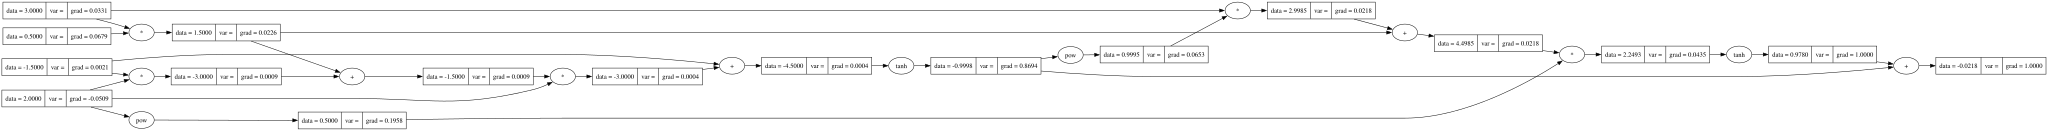

In [77]:
out.backward()

draw_dot(out)

In [78]:
# the same above expression calculated using finite differences 

In [81]:
eps = 1e-6

def central_diff(a):
    a1 = Value(a.data + eps)
    a2 = Value(a.data - eps)
    out_plus = forward_pass(a1, b, c, d).data
    out_minus = forward_pass(a2, b, c, d).data
    finite_da = (out_plus - out_minus) / (2 * eps)
    return finite_da
print("backprop da (from engine) =", a.grad)
print("finite da (central difference)   =", central_diff(a))
print("the difference is very small")

#Similarly you can try out for b, c and d variables also

backprop da (from engine) = -0.050883673686819356
finite da (central difference)   = -0.05088367371897107
the difference is very small
